COMP 3610 Assignment 3 
Part 1
Task 1.1: Spark Setup and Data Loading
Preface: Spark didnt work locally so I used collab for that part and did the rest locally

In [ ]:

import time
import pandas as pd
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("COMP3610_Assignment3_NYC_Taxi")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("Warn")
print(f"Spark version: {spark.version}")
print(f"Application name: {spark.sparkContext.appName}")

KeyboardInterrupt: 

In [ ]:
import urllib.request
import os

DATA_PATH = "yellow_tripdata_2024-01.parquet"

if not os.path.exists(DATA_PATH):
    print("Downloading NYC Yellow Taxi data...")
    url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
    urllib.request.urlretrieve(url, DATA_PATH)
    print("Download complete!")
else:
    print("Data file already exists, skipping download.")

spark_start = time.time()
df_raw = spark.read.parquet(DATA_PATH)
spark_row_count = df_raw.count()
spark_load_time = time.time() - spark_start

pandas_start = time.time()
df_pandas = pd.read_parquet(DATA_PATH)
pandas_load_time = time.time() - pandas_start

print(f"\nLoad Time Comparison")
print(f"Spark  load time : {spark_load_time:.2f}s  ({spark_row_count:,} rows)")
print(f"Pandas load time : {pandas_load_time:.2f}s  ({len(df_pandas):,} rows)")
print(f"\nInterpretation: Spark has higher overhead on a single machine due to JVM")
print(f"startup and task scheduling. However, Spark scales across clusters and handles")
print(f"datasets far exceeding available RAM, making it essential for big data workloads.")


Load Time Comparison
Spark  load time : 5.06s  (2,964,624 rows)
Pandas load time : 1.49s  (2,964,624 rows)

Interpretation: Spark has higher overhead on a single machine due to JVM
startup and task scheduling. However, Spark scales across clusters and handles
datasets far exceeding available RAM, making it essential for big data workloads.


In [26]:
print(f"DataFrame Schema")
df_raw.printSchema()
print(f"\nTotal Rows: {spark_row_count:,}")
print(f"\nPartition Information: {df_raw.rdd.getNumPartitions()}")

DataFrame Schema
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)


Total Rows: 2,964,624

Partition Information: 2


Part 1.2 : Data Cleaning and Feature Engineering

In [27]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

critical_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "trip_distance"
]

initial_count = df_raw.count()
print(f"Initial Row Count: {initial_count:,}")

df_no_nulls = df_raw.dropna(subset = critical_cols)
after_null_drop = df_no_nulls.count()
print(f"After Null Drop: {after_null_drop:,} (removed {initial_count - after_null_drop:,}")

df_filtered = df_no_nulls.filter(
    (F.col("trip_distance") > 0) &
    (F.col("fare_amount") >= 0) &
    (F.col("fare_amount") <= 500) &
    (F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime"))
)

after_filter = df_filtered.count()
print(f"After Filter: {after_filter:,} (removed {after_null_drop - after_filter:,}")
print(f"Total rows removed: {initial_count - after_filter:,}")

Initial Row Count: 2,964,624
After Null Drop: 2,964,624 (removed 0
After Filter: 2,870,046 (removed 94,578
Total rows removed: 94,578


In [28]:
df_clean = df_filtered.withColumn(
    "trip_duration_minutes",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "trip_speed_mph",
    F.when(
        F.col("trip_duration_minutes") > 0,
        F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
    ).otherwise(F.lit(None).cast(DoubleType()))
).withColumn(
    "pickup_hour",
    F.hour("tpep_pickup_datetime")
).withColumn(
    "pickup_day_of_week",
    F.dayofweek("tpep_pickup_datetime")
).withColumn(
    "tip_percentage",
    F.when(
        F.col("fare_amount") > 0,
        (F.col("tip_amount") / F.col("fare_amount")) * 100
    ).otherwise(F.lit(0.0))
)

print("Derived Columns:")
df_clean.select(
    "tpep_pickup_datetime", "trip_distance", "fare_amount",
    "trip_duration_minutes", "trip_speed_mph",
    "pickup_hour", "pickup_day_of_week", "tip_percentage"
).show(5, truncate=False)

print(f"\nClean row count: {df_clean.count():,}")


Derived Columns:
+--------------------+-------------+-----------+---------------------+------------------+-----------+------------------+------------------+
|tpep_pickup_datetime|trip_distance|fare_amount|trip_duration_minutes|trip_speed_mph    |pickup_hour|pickup_day_of_week|tip_percentage    |
+--------------------+-------------+-----------+---------------------+------------------+-----------+------------------+------------------+
|2024-01-01 00:57:55 |1.72         |17.7       |19.8                 |5.212121212121212 |0          |2                 |0.0               |
|2024-01-01 00:03:00 |1.8          |10.0       |6.6                  |16.363636363636363|0          |2                 |37.5              |
|2024-01-01 00:17:06 |4.7          |23.3       |17.916666666666668   |15.739534883720932|0          |2                 |12.875536480686694|
|2024-01-01 00:36:38 |1.4          |10.0       |8.3                  |10.120481927710843|0          |2                 |20.0              |
|20

In [29]:
df_clean.createOrReplaceTempView("taxi_trips")
print("View 'taxi_trips' registered.")

View 'taxi_trips' registered.


Task 1.3: Spark Sql Analysis

In [30]:
print("Query 1: Top 10 Busiest Pickup Hours")
q1 = spark.sql("""
    SELECT
        pickup_hour,
        COUNT(*)                        AS trip_count,
        ROUND(AVG(fare_amount), 2)      AS avg_fare,
        ROUND(AVG(tip_percentage), 2)   AS avg_tip_percent
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""")
q1.show()

print("Interpretation: \n\nEvening hours around 3 p.m onwards have the majority of trip volume, this is because of after work commuting.")
print("\nTip percentages tend to hover around 20% with the highest being ~2% more at night")

Query 1: Top 10 Busiest Pickup Hours
+-----------+----------+--------+---------------+
|pickup_hour|trip_count|avg_fare|avg_tip_percent|
+-----------+----------+--------+---------------+
|         18|    206281|   17.01|          22.78|
|         17|    200310|   18.12|          22.34|
|         16|    184968|   19.46|          21.83|
|         15|    184004|   19.11|           19.8|
|         19|    178810|   17.63|          22.86|
|         14|    178026|   19.27|           19.8|
|         13|    165355|   18.42|          19.78|
|         12|    159912|    17.8|          19.74|
|         21|    155910|   18.29|          21.88|
|         20|    155559|   18.05|          22.17|
+-----------+----------+--------+---------------+

Interpretation: 

Evening hours around 3 p.m onwards have the majority of trip volume, this is because of after work commuting.

Tip percentages tend to hover around 20% with the highest being ~2% more at night


In [ ]:
print("Query 2: Average trip speed by day of the week")
q2 = spark.sql("""
    SELECT
        CASE pickup_day_of_week
            WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
            WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
            WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
            WHEN 7 THEN 'Saturday'
        END                                  AS day_of_week,
        ROUND(AVG(trip_speed_mph), 2)        AS avg_speed_mph,
        ROUND(AVG(trip_distance), 2)         AS avg_distance_miles,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_mins
    FROM taxi_trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed_mph DESC
""")
q2.show()
print("Interpretation: \n\nThere are higher average speeds on Tuesdays and Mondays because there is less congestion and traffic which allows for higher speeds.")
print("\nIn the later end of the week, there is more traffic due to work commuting to and from, which lowers avg speed ")

Query 2: Average trip speed by day of the week
+-----------+-------------+------------------+-----------------+
|day_of_week|avg_speed_mph|avg_distance_miles|avg_duration_mins|
+-----------+-------------+------------------+-----------------+
|    Tuesday|        17.46|              4.25|            16.18|
|     Sunday|        15.97|               3.9|            14.32|
|     Monday|        13.85|              3.77|            15.85|
|     Friday|        13.41|              3.68|            15.93|
|   Saturday|        13.26|              3.39|             14.9|
|   Thursday|        12.48|              3.54|            16.43|
|  Wednesday|        12.38|              3.61|            16.26|
+-----------+-------------+------------------+-----------------+

Interpretation: 

There are higher average speeds on Tuesdays and Mondays because there is less congestion and traffic which allows for higher speeds.

In the later end of the week, there is more traffic due to work commuting to and from

In [ ]:
print("Query 3: Top 5 Pickup Locations by Revenue per Day")
q3 = spark.sql("""
    WITH revenue_by_day_location AS (
        SELECT
            CASE pickup_day_of_week
                WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
                WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
                WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
                WHEN 7 THEN 'Saturday'
            END                             AS day_of_week,
            pickup_day_of_week,
            PULocationID                    AS pickup_location,
            ROUND(SUM(total_amount), 2)     AS total_revenue,
            COUNT(*)                        AS trip_count
        FROM taxi_trips
        GROUP BY pickup_day_of_week, PULocationID
    ),
    ranked AS (
        SELECT *,
            RANK() OVER (
                PARTITION BY pickup_day_of_week
                ORDER BY total_revenue DESC
            ) AS revenue_rank
        FROM revenue_by_day_location
    )
    SELECT day_of_week, pickup_location, total_revenue, trip_count, revenue_rank
    FROM ranked
    WHERE revenue_rank <= 5
    ORDER BY pickup_day_of_week, revenue_rank
""")
q3.show(35, truncate=False)
print("Interpretation: \n\nA small set of high-traffic zones (JFK, LaGuardia, Midtown)")
print("dominate revenue across all days. Airport locations rank higher on weekends.")

Query 3: Top 5 Pickup Locations by Revenue per Day
+-----------+---------------+-------------+----------+------------+
|day_of_week|pickup_location|total_revenue|trip_count|revenue_rank|
+-----------+---------------+-------------+----------+------------+
|Sunday     |132            |1564287.93   |19526     |1           |
|Sunday     |138            |763398.54    |12038     |2           |
|Sunday     |230            |346553.95    |12736     |3           |
|Sunday     |186            |264131.38    |11092     |4           |
|Sunday     |79             |263467.74    |12263     |5           |
|Monday     |132            |2054606.73   |25282     |1           |
|Monday     |138            |1021138.28   |15656     |2           |
|Monday     |161            |460145.28    |19338     |3           |
|Monday     |236            |373008.89    |18502     |4           |
|Monday     |237            |372575.48    |19214     |5           |
|Tuesday    |132            |1794987.56   |22384     |1          

In [ ]:
print("Query 4: Cumulative Trip Count by Hour")
q4 = spark.sql("""
    WITH hourly_counts AS (
        SELECT pickup_hour, COUNT(*) AS trips_this_hour
        FROM taxi_trips
        GROUP BY pickup_hour
    ),
    cumulative AS (
        SELECT pickup_hour, trips_this_hour,
            SUM(trips_this_hour) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
        FROM hourly_counts
    )
    SELECT pickup_hour, trips_this_hour, cumulative_trips,
        ROUND(cumulative_trips * 100.0 / SUM(trips_this_hour) OVER (), 2) AS cumulative_pct
    FROM cumulative
    ORDER BY pickup_hour
""")
q4.show(24)

crossover = q4.filter(F.col("cumulative_pct") >= 50).orderBy("pickup_hour").first()
print(f"\n50% of daily trips completed by hour: {crossover['pickup_hour']}:00 ({crossover['cumulative_percent']}%)")

print("Interpretation: \n\nThe 50% threshold is crossed in the early afternoon around 3 pm, which means trip activity is concentrated to the later half of the day")


Query 4: Cumulative Trip Count by Hour
+-----------+---------------+----------------+--------------+
|pickup_hour|trips_this_hour|cumulative_trips|cumulative_pct|
+-----------+---------------+----------------+--------------+
|          0|          75247|           75247|          2.62|
|          1|          50490|          125737|          4.38|
|          2|          34976|          160713|          5.60|
|          3|          22947|          183660|          6.40|
|          4|          15284|          198944|          6.93|
|          5|          17495|          216439|          7.54|
|          6|          39415|          255854|          8.91|
|          7|          80870|          336724|         11.73|
|          8|         113506|          450230|         15.69|
|          9|         125619|          575849|         20.06|
|         10|         135425|          711274|         24.78|
|         11|         146754|          858028|         29.90|
|         12|         159912|  

In [ ]:
print("Query 5: Short vs Medium vs Long trip comparison")
q5 = spark.sql("""
    SELECT
        CASE
            WHEN trip_distance < 2   THEN 'Short (<2 miles)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 miles)'
            ELSE                          'Long (>10 miles)'
        END                              AS trip_category,
        COUNT(*)                         AS trip_count,
        ROUND(AVG(fare_amount), 2)       AS avg_fare,
        ROUND(AVG(trip_distance), 2)     AS avg_distance,
        ROUND(AVG(tip_percentage), 2)    AS avg_tip_percent
    FROM taxi_trips
    GROUP BY trip_category
    ORDER BY avg_distance
""")
q5.show()

print("Interpretation: \n\nShort Trips have the most trip count volume by far as well as the smallest fare")
print("\nThe tip percentage is the highest in the short followed by long")
print("\nLong trips have the highest avg fare as well as the least amount of trips")

Query 5: Short vs Medium vs Long trip comparison
+-------------------+----------+--------+------------+---------------+
|      trip_category|trip_count|avg_fare|avg_distance|avg_tip_percent|
+-------------------+----------+--------+------------+---------------+
|   Short (<2 miles)|   1642438|    9.91|        1.13|          23.07|
|Medium (2-10 miles)|   1002534|   22.18|        3.96|          18.57|
|   Long (>10 miles)|    225074|   64.65|        21.7|          21.93|
+-------------------+----------+--------+------------+---------------+

Interpretation: 

Short Trips have the most trip count volume by far as well as the smallest fare

The tip percentage is the highest in the short followed by long

Long trips have the highest avg fare as well as the least amount of trips


Task 1.4: Performance Optimization

In [ ]:
def run_benchmark_query():
  return spark.sql("""
      SELECT pickup_hour, COUNT(*) AS trips, ROUND(AVG(fare_amount), 2) AS avg_fare
        FROM taxi_trips
        GROUP BY pickup_hour ORDER BY pickup_hour
    """).collect()

t0 = time.time()
run_benchmark_query()
time_before = time.time() - t0
print(f"Query time before optimization: {time_before:.2f}s")

df_clean.cache()
df_clean.count()

t1 = time.time()
run_benchmark_query()
time_after = time.time() - t1
print(f"Query time after optimization: {time_after:.2f}s")
print(f"Speedup: {time_before / time_after:.1f}x")

print("\nInterpretation: Caching stores the dataframe in memory so spark avoids rescanning the parquet files on every action, giving faster repeated queries")

Query time before optimization: 1.01s
Query time after optimization: 0.63s
Speedup: 1.6x

Interpretation: Caching stores the dataframe in memory so spark avoids rescanning the parquet files on every action, giving faster repeated queries


In [ ]:
OUTPUT_PATH = "cleaned_taxi_partitioned"

print("Writing partitioned parquet files...")
t_write = time.time()
df_clean.write.mode("overwrite").partitionBy("pickup_hour").parquet(OUTPUT_PATH)
print(f"Write complete in {time.time() - t_write:.2f}s")

t_prune = time.time()
df_hour17 = spark.read.parquet(f"{OUTPUT_PATH}/pickup_hour=17")
count_17 = df_hour17.count()
print(f"\nRows in hour 17 partition  : {count_17:,}")
print(f"Read time (single partition): {time.time() - t_prune:.2f}s")

print("\nPartition pruning means spark reads 1 of 24 directories instead of the full dataset, reducing data scanned")

Writing partitioned parquet files...
Write complete in 25.08s

Rows in hour 17 partition  : 200,310
Read time (single partition): 0.41s


In [ ]:
print("Physical Execution Plan")
spark.sql("""
    SELECT pickup_hour, COUNT(*) AS trip_count,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""").explain(mode="simple")

Physical Execution Plan
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[trip_count#7363L DESC NULLS LAST], output=[pickup_hour#114,trip_count#7363L,avg_fare#7364])
   +- HashAggregate(keys=[pickup_hour#114], functions=[count(1), avg(fare_amount#10)])
      +- Exchange hashpartitioning(pickup_hour#114, 200), ENSURE_REQUIREMENTS, [plan_id=2744]
         +- HashAggregate(keys=[pickup_hour#114], functions=[partial_count(1), partial_avg(fare_amount#10)])
            +- InMemoryTableScan [fare_amount#10, pickup_hour#114]
                  +- InMemoryRelation [VendorID#0, tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#3L, trip_distance#4, RatecodeID#5L, store_and_fwd_flag#6, PULocationID#7, DOLocationID#8, payment_type#9L, fare_amount#10, extra#11, mta_tax#12, tip_amount#13, tolls_amount#14, improvement_surcharge#15, total_amount#16, congestion_surcharge#17, Airport_fee#18, trip_duration_minutes#112, trip_speed_mph#113, pic

In [ ]:
df_clean.unpersist()
print("Cache cleared")

Cache cleared


Part 2: RAG Pipeline over Transportation Documents
Task 2.1: Document Collection and Ingestion

In [4]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
import chromadb
import matplotlib.pyplot as plt
import seaborn as sns

docs_path = "docs"
pdf_files = [f for f in os.listdir(docs_path) if f.endswith(".pdf")]

print(f"Found {len(pdf_files)} PDFs:")
for f in pdf_files:
    print(f"  - {f}")

c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 5 PDFs:
  - 25-38 NYC Delivery Worker Data Collection and Research Report.pdf
  - annual_report_2023.pdf
  - mta-annual-report-2023.3.pdf
  - NYC-Vision-Zero-Investment.pdf
  - stratplan_compplan.pdf


In [5]:
all_documents = []
extraction_stats = []

for pdf_file in pdf_files:
    path = os.path.join(docs_path, pdf_file)
    try:
        loader = PyPDFLoader(path)
        pages = loader.load()
        total_chars = sum(len(p.page_content) for p in pages)
        all_documents.extend(pages)
        extraction_stats.append({
            "file": pdf_file,
            "pages": len(pages),
            "characters": total_chars,
            "avg_chars_per_page": total_chars // len(pages) if pages else 0
        })
        print(f"Worked {pdf_file}: {len(pages)} pages, {total_chars:,} chars")
    except Exception as e:
        print(f"No Worked {pdf_file}: FAILED — {e}")

total_pages = sum(s["pages"] for s in extraction_stats)
total_chars = sum(s["characters"] for s in extraction_stats)

print(f"Extraction Summary")
print(f"Total documents: {len(pdf_files)}")
print(f"Total pages: {total_pages}")
print(f"Total characters: {total_chars:,}")
print(f"Total doc chunks: {len(all_documents)}")

Worked 25-38 NYC Delivery Worker Data Collection and Research Report.pdf: 104 pages, 164,461 chars
Worked annual_report_2023.pdf: 18 pages, 39,183 chars
Worked mta-annual-report-2023.3.pdf: 33 pages, 52,778 chars
Worked NYC-Vision-Zero-Investment.pdf: 15 pages, 34,554 chars
Worked stratplan_compplan.pdf: 39 pages, 107,844 chars
Extraction Summary
Total documents: 5
Total pages: 209
Total characters: 398,820
Total doc chunks: 209


Task 2.2: Chunking and Embedding

Chunks with size 500: 1060
Chunks with size 1000: 562
Chunks with size 2000: 321


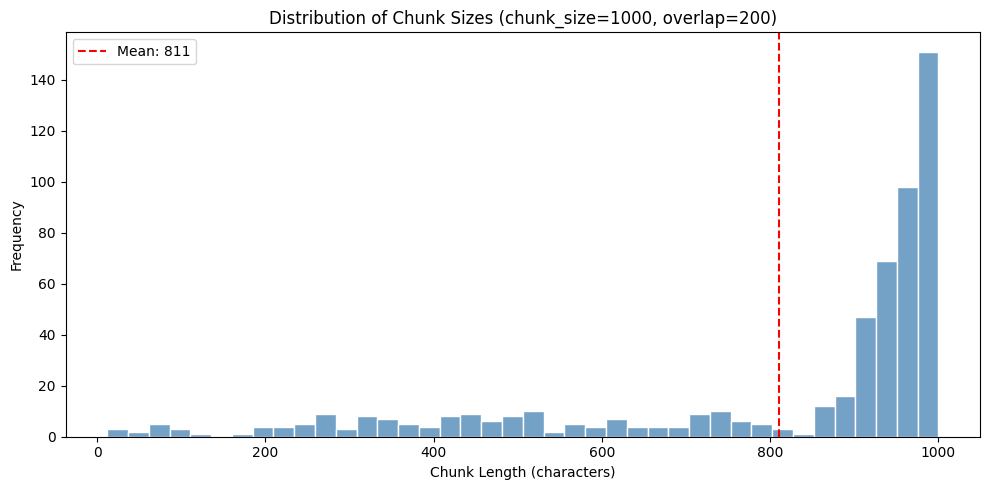


Min chunk size: 12
Max chunk size: 1000
Mean chunk size: 811


In [6]:
splitter_1000 = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks_1000 = splitter_1000.split_documents(all_documents)

splitter_500 = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks_500 = splitter_500.split_documents(all_documents)

splitter_2000 = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=400)
chunks_2000 = splitter_2000.split_documents(all_documents)

print(f"Chunks with size 500: {len(chunks_500)}")
print(f"Chunks with size 1000: {len(chunks_1000)}")
print(f"Chunks with size 2000: {len(chunks_2000)}")

chunk_lengths = [len(c.page_content) for c in chunks_1000]

plt.figure(figsize=(10, 5))
sns.histplot(chunk_lengths, bins=40, color="steelblue", edgecolor="white")
plt.title("Distribution of Chunk Sizes (chunk_size=1000, overlap=200)")
plt.xlabel("Chunk Length (characters)")
plt.ylabel("Frequency")
plt.axvline(x=sum(chunk_lengths)/len(chunk_lengths), color="red", linestyle="--", label=f"Mean: {sum(chunk_lengths)/len(chunk_lengths):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMin chunk size: {min(chunk_lengths)}")
print(f"Max chunk size: {max(chunk_lengths)}")
print(f"Mean chunk size: {sum(chunk_lengths)/len(chunk_lengths):.0f}")

In [7]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

print("Loading embedding model")
embedding_fn = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

chroma_client = chromadb.PersistentClient(path="chroma_db")

try:
    chroma_client.delete_collection("taxi_docs")
except:
    pass

collection = chroma_client.create_collection(
    name="taxi_docs",
    embedding_function=embedding_fn
)

print(f"Embedding and storing {len(chunks_1000)} chunks...")

batch_size = 50
for i in range(0, len(chunks_1000), batch_size):
    batch = chunks_1000[i:i+batch_size]
    collection.add(
        documents=[c.page_content for c in batch],
        metadatas=[{
            "source": c.metadata.get("source", "unknown").split("/")[-1],
            "page": c.metadata.get("page", 0)
        } for c in batch],
        ids=[f"chunk_{i+j}" for j, c in enumerate(batch)]
    )
    if (i // batch_size) % 5 == 0:
        print(f"  Stored {min(i+batch_size, len(chunks_1000))}/{len(chunks_1000)} chunks...")

print(f"\nChromaDB collection 'taxi_docs' ready")
print(f"  Total chunks stored: {collection.count()}")

Loading embedding model
Embedding and storing 562 chunks...
  Stored 50/562 chunks...
  Stored 300/562 chunks...
  Stored 550/562 chunks...

ChromaDB collection 'taxi_docs' ready
  Total chunks stored: 562


Task 2.3: RAG Pipeline Implementation

In [8]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

def build_temp_collection(chunks, name):
    try:
        chroma_client.delete_collection(name)
    except:
        pass
    col = chroma_client.create_collection(name, embedding_function=embedding_fn)
    batch_size = 50
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i:i+batch_size]
        col.add(
            documents=[c.page_content for c in batch],
            metadatas=[{"source": c.metadata.get("source","").split("/")[-1],
                        "page": c.metadata.get("page", 0)} for c in batch],
            ids=[f"chunk_{i+j}" for j, c in enumerate(batch)]
        )
    return col

print("Building collections for experiment")
col_500  = build_temp_collection(chunks_500,  "taxi_docs_500")
col_2000 = build_temp_collection(chunks_2000, "taxi_docs_2000")
print("Done!")

sample_queries = [
    "What are the TLC regulations for taxi drivers?",
    "How has MTA ridership changed in recent years?",
    "What is the Vision Zero initiative?"
]

for query in sample_queries:
    print(f"Query: {query}")
    for label, col in [("500", col_500), ("1000", collection), ("2000", col_2000)]:
        results = col.query(query_texts=[query], n_results=3)
        print(f"\nChunk size {label} ")
        for i, doc in enumerate(results["documents"][0]):
            src = results["metadatas"][0][i]["source"]
            pg  = results["metadatas"][0][i]["page"]
            print(f"  [{i+1}] ({src}, p.{pg}) {doc[:120]}")

print(f"""
Chunk Size Analysis
Chunk size 1000 retrieves the most relevant results for queries
Size 500 chunks are very grandular, often capturing only part of a concept,
splitting key context across multiple chunks and reducing coherence per result.
Size 2000 chunks are too wide spread, they contain multiple topics in one chunk,
making the retrieved text less focused on the specific query.
Size 1000 strikes the best balance, enough context to be meaningful, but
focused enough to match specific questions accurately.
""")

Building collections for experiment
Done!
Query: What are the TLC regulations for taxi drivers?

Chunk size 500 
  [1] (docs\annual_report_2023.pdf, p.5) 5 | 202 3  A n n u a l  R e p o r t  
 
Licensees Regulated by TLC 
 
The Taxi & Limousine Commission licenses and regul
  [2] (docs\annual_report_2023.pdf, p.3) 3 | 202 3  A n n u a l  R e p o r t  
 
Mission and Budget 
 
The Taxi and Limousine Commission (TLC), created by Local 
  [3] (docs\annual_report_2023.pdf, p.8) 8 | 202 3  A n n u a l  R e p o r t  
 
Taxi Electric Vehicle 
TLC amended its existing vehicle specifications governing

Chunk size 1000 
  [1] (docs\annual_report_2023.pdf, p.8) 8 | 202 3  A n n u a l  R e p o r t  
 
Taxi Electric Vehicle 
TLC amended its existing vehicle specifications governing
  [2] (docs\annual_report_2023.pdf, p.5) 5 | 202 3  A n n u a l  R e p o r t  
 
Licensees Regulated by TLC 
 
The Taxi & Limousine Commission licenses and regul
  [3] (docs\annual_report_2023.pdf, p.1) 1 | 202 3  A n n u

In [ ]:
from openai import OpenAI
import json

llm_client = OpenAI(
    api_key="API_KEY_HERE",       
    base_url="https://synapse.sergiomathurin.com/v1" 
)

response = llm_client.chat.completions.create(
    model="llama3-8b-instruct",
    messages=[{"role": "user", "content": "Say hello in one sentence."}],
    max_tokens=50
)
print(response.choices[0].message.content)

Hello, how can I assist you today?


In [9]:

def retrieve_chunks(query, n_results=5):
    results = collection.query(query_texts=[query], n_results=n_results)
    chunks = []
    for i in range(len(results["documents"][0])):
        chunks.append({
            "text": results["documents"][0][i],
            "source": results["metadatas"][0][i]["source"],
            "page": results["metadatas"][0][i]["page"]
        })
    return chunks

def build_prompt(query, chunks):
    context = ""
    for i, chunk in enumerate(chunks):
        context += f"\n[Source {i+1}: {chunk['source']}, Page {chunk['page']}]\n{chunk['text']}\n"

    prompt = f"""You are an expert on NYC transportation policy
Answer the question below using ONLY the provided context.
If the context does not contain enough information, say "I don't have enough information"
Always cite the source document and page number for each claim you make, e.g. (annual_report_2023.pdf, p.5).

CONTEXT:
{context}

QUESTION: {query}

ANSWER:"""
    return prompt

def rag_query(query, n_results=5, verbose=True):
    if verbose:
        print(f"\n{'='*60}")
        print(f"Question: {query}")
        print(f"{'='*60}")

    chunks = retrieve_chunks(query, n_results)
    if verbose:
        print(f"\nRetrieved {len(chunks)} chunks")
        for i, c in enumerate(chunks):
            print(f"  [{i+1}] {c['source']}, p.{c['page']}: {c['text'][:80]}")

    prompt = build_prompt(query, chunks)
    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400
    )
    answer = response.choices[0].message.content

    if verbose:
        print(f"\nGenerated Answer")
        print(answer)
        print(f"\nSources Used")
        for c in chunks:
            print(f"  {c['source']}, p.{c['page']}")

    return {"query": query, "chunks": chunks, "answer": answer}

test_questions = [
    "What are the main goals of the NYC Vision Zero initiative?",
    "How does the TLC regulate taxi driver licensing?",
    "What sustainability initiatives has the NYC DOT implemented?",
    "How has MTA ridership and revenue changed recently?",
    "What challenges do delivery workers face in NYC?"
]

rag_results = []
for q in test_questions:
    r = rag_query(q)
    rag_results.append(r)

print("\nRAG pipeline complete")


Question: What are the main goals of the NYC Vision Zero initiative?

Retrieved 5 chunks
  [1] docs\NYC-Vision-Zero-Investment.pdf, p.0: THE VISION ZERO INVESTMENT
WHY NEW YORK MUST REBUILD ITS MOST DANGEROUS STREETS 
  [2] docs\NYC-Vision-Zero-Investment.pdf, p.2: Atlanta, and the results are dangerous for everyone.
In the winter of 2014, Mayo
  [3] docs\NYC-Vision-Zero-Investment.pdf, p.6: 9
POLICY RECOMMENDATIONS
In order to achieve Vision Zero, New York City must pri
  [4] docs\NYC-Vision-Zero-Investment.pdf, p.5: a down payment on future capital reconstruction.
The approximately 60 projects c
  [5] docs\stratplan_compplan.pdf, p.22: useful information about these projects as well as for a myriad of day-to-day 
N

Generated Answer
The main goals of the NYC Vision Zero initiative, as outlined in the provided documents, are to eliminate all traffic deaths and serious injuries on New York City streets (docs\NYC-Vision-Zero-Investment.pdf, p.2). To achieve this goal, the initiative ai

Task 2.4: RAG Evaluation and Analysis

In [19]:
test_set = [
    {
        "question": "What is the main goal of Vision Zero?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["traffic deaths", "eliminate", "safer", "streets"]
    },
    {
        "question": "What drug test requirements exist for TLC taxi drivers?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["drug test", "fingerprint", "license"]
    },
    {
        "question": "What is the TLC mission statement?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["safety", "licensees", "taxi", "limousine"]
    },
    {
        "question": "What speed limit did NYC adopt for Vision Zero?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["25 mph", "speed limit"]
    },
    {
        "question": "How many days a week do most NYC delivery workers work?",
        "expected_source": "25-38 NYC Delivery Worker Data Collection and Research Report.pdf",
        "expected_answer_keywords": ["5 days", "86", "week"]
    },
    {
        "question": "What is the NYC DOT sustainable streets plan about?",
        "expected_source": "stratplan_compplan.pdf",
        "expected_answer_keywords": ["sustainable", "transportation", "DOT", "streets"]
    },
    {
        "question": "What vehicle greening initiatives did NYC DOT pursue?",
        "expected_source": "stratplan_compplan.pdf",
        "expected_answer_keywords": ["fleet", "green", "vehicle", "environment"]
    },
    {
        "question": "What types of licenses does the TLC issue?",
        "expected_source": "annual_report_2023.pdf",
        "expected_answer_keywords": ["paratransit", "commuter van", "driver", "license"]
    },
    {
        "question": "What e-bike or electric vehicle challenges do delivery workers face?",
        "expected_source": "25-38 NYC Delivery Worker Data Collection and Research Report.pdf",
        "expected_answer_keywords": ["battery", "electric", "e-bike", "charging"]
    },
    {
        "question": "What policy recommendations does Vision Zero make?",
        "expected_source": "NYC-Vision-Zero-Investment.pdf",
        "expected_answer_keywords": ["reconstruct", "arterial", "speed", "enforcement"]
    },
]

evaluation_results = []

for item in test_set:
    result = rag_query(item["question"], verbose=False)

    retrieved_sources = [c["source"] for c in result["chunks"]]
    retrieval_correct = item["expected_source"] in retrieved_sources

    answer_lower = result["answer"].lower()
    keywords_found = [kw for kw in item["expected_answer_keywords"] if kw.lower() in answer_lower]
    answer_correct = len(keywords_found) >= len(item["expected_answer_keywords"]) // 2

    evaluation_results.append({
        "question": item["question"],
        "retrieval_correct": retrieval_correct,
        "answer_correct": answer_correct,
        "both_correct": retrieval_correct and answer_correct,
        "retrieved_sources": retrieved_sources,
        "expected_source": item["expected_source"],
        "keywords_found": keywords_found,
        "expected_keywords": item["expected_answer_keywords"],
        "answer": result["answer"]
    })

print(f"{'Question':<45} {'Retrieval':>10} {'Answer':>8} {'Both':>6}")
for r in evaluation_results:
    q_short = r["question"][:43] + ".." if len(r["question"]) > 43 else r["question"]
    print(f"{q_short:<45} {'✓' if r['retrieval_correct'] else '✗':>10} {'✓' if r['answer_correct'] else '✗':>8} {'✓' if r['both_correct'] else '✗':>6}")

retrieval_acc = sum(r["retrieval_correct"] for r in evaluation_results) / len(evaluation_results) * 100
answer_acc = sum(r["answer_correct"] for r in evaluation_results) / len(evaluation_results) * 100
both_acc = sum(r["both_correct"] for r in evaluation_results) / len(evaluation_results) * 100

print(f"\nAccuracy Metrics")
print(f"Retrieval accuracy: {retrieval_acc:.0f}%")
print(f"Answer accuracy: {answer_acc:.0f}%")
print(f"Full accuracy: {both_acc:.0f}%")

print(f"\nError Analysis")
for r in evaluation_results:
    if not r["both_correct"]:
        if not r["retrieval_correct"]:
            print(f"\n[RETRIEVAL FAILURE] {r['question']}")
            print(f"  Expected: {r['expected_source']}")
            print(f"  Got: {r['retrieved_sources']}")
            print(f"  Fix: Smaller chunk size or better metadata filtering may help")
        elif not r["answer_correct"]:
            print(f"\n[GENERATION FAILURE] {r['question']}")
            print(f"  Keywords found: {r['keywords_found']}")
            print(f"  Keywords expected: {r['expected_keywords']}")
            print(f"  Fix: More specific prompt or larger context window may help")

print(f"""
Discussion
Retrieval failures occur when the correct source document is not among the
top-k retrieved chunks.
Generation failures occur when the correct chunks are retrieved but the LLM
produces an inaccurate or incomplete answer. This can be improved with better
prompt engineering, or a better credit model
""")

Question                                       Retrieval   Answer   Both
What is the main goal of Vision Zero?                  ✓        ✓      ✓
What drug test requirements exist for TLC t..          ✓        ✓      ✓
What is the TLC mission statement?                     ✓        ✓      ✓
What speed limit did NYC adopt for Vision Z..          ✓        ✓      ✓
How many days a week do most NYC delivery w..          ✓        ✓      ✓
What is the NYC DOT sustainable streets pla..          ✓        ✓      ✓
What vehicle greening initiatives did NYC D..          ✓        ✓      ✓
What types of licenses does the TLC issue?             ✓        ✓      ✓
What e-bike or electric vehicle challenges ..          ✓        ✓      ✓
What policy recommendations does Vision Zer..          ✓        ✓      ✓

Accuracy Metrics
Retrieval accuracy: 100%
Answer accuracy: 100%
Full accuracy: 100%

Error Analysis

Discussion
Retrieval failures occur when the correct source document is not among the
top-k ret

Part 3: Integrated Analytics Application
Task 3.1: Query Router

In [ ]:
def route_query(question):
    system_prompt = """You are a query router for an NYC taxi analytics system.
Classify the user's question into exactly one of these categories:

- DATA: Questions answerable from structured NYC Yellow Taxi trip data
  (fares, tips, distances, trip counts, speeds, pickup times, locations)
- DOCUMENT: Questions answerable from NYC transportation policy documents
  (TLC regulations, Vision Zero, DOT plans, delivery worker reports, MTA)
- HYBRID: Questions requiring BOTH the taxi data AND policy documents

Respond with ONLY valid JSON in this exact format:
{"category": "DATA", "reasoning": "brief reason"}

No other text, just the JSON."""

    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": question}
        ],
        max_tokens=100
    )

    raw = response.choices[0].message.content.strip()

    try:
        result = json.loads(raw)
    except:
        if "DATA" in raw:
            result = {"category": "DATA", "reasoning": "parsed from response"}
        elif "DOCUMENT" in raw:
            result = {"category": "DOCUMENT", "reasoning": "parsed from response"}
        else:
            result = {"category": "HYBRID", "reasoning": "ambiguous — defaulting to HYBRID"}

    return result

test_queries = [
    {"question": "What was the average fare on Mondays?", "expected": "DATA"},
    {"question": "Which hour had the most taxi trips in January 2024?","expected": "DATA"},
    {"question": "What is the average tip percentage for long trips?", "expected": "DATA"},
    {"question": "How many trips were taken on weekends?", "expected": "DATA"},
    {"question": "What is the average trip speed during rush hour?", "expected": "DATA"},

    {"question": "What are the TLC licensing requirements for drivers?", "expected": "DOCUMENT"},
    {"question": "What is the Vision Zero initiative?", "expected": "DOCUMENT"},
    {"question": "What sustainability goals does the NYC DOT have?", "expected": "DOCUMENT"},
    {"question": "What challenges do delivery workers face in NYC?", "expected": "DOCUMENT"},
    {"question": "What are TLC regulations on vehicle inspections?", "expected": "DOCUMENT"},

    {"question": "How do actual tipping patterns compare to TLC recommendations?", "expected": "HYBRID"},
    {"question": "Do taxi trip speeds meet NYC DOT safety targets?", "expected": "HYBRID"},
    {"question": "How do real fare amounts compare to TLC regulated fare structures?", "expected": "HYBRID"},
    {"question": "Are taxi pickup patterns consistent with Vision Zero street priorities?", "expected": "HYBRID"},
    {"question": "How does actual taxi usage compare to MTA policy goals?", "expected": "HYBRID"},
]

print(f"{'Question':<55} {'Expected':>10} {'Got':>10} {'Correct':>4}")

correct = 0
router_results = []

for item in test_queries:
    result = route_query(item["question"])
    got = result.get("category", "HYBRID")
    is_correct = got == item["expected"]
    if is_correct:
        correct += 1
    router_results.append({**item, "got": got, "reasoning": result.get("reasoning",""), "correct": is_correct})
    q_short = item["question"][:53] + ".." if len(item["question"]) > 53 else item["question"]
    print(f"{q_short:<55} {item['expected']:>10} {got:>10} {'✓' if is_correct else '✗':>4}")

accuracy = correct / len(test_queries) * 100
print(f"\nRouter classification accuracy: {correct}/{len(test_queries)} = {accuracy:.0f}%")
print(f"\nEdge case handling: Ambiguous queries default to hybrid to ensure both data and document backends are consulted")

Question                                                  Expected        Got Correct
What was the average fare on Mondays?                         DATA       DATA    ✓
Which hour had the most taxi trips in January 2024?           DATA       DATA    ✓
What is the average tip percentage for long trips?            DATA       DATA    ✓
How many trips were taken on weekends?                        DATA       DATA    ✓
What is the average trip speed during rush hour?              DATA       DATA    ✓
What are the TLC licensing requirements for drivers?      DOCUMENT   DOCUMENT    ✓
What is the Vision Zero initiative?                       DOCUMENT   DOCUMENT    ✓
What sustainability goals does the NYC DOT have?          DOCUMENT   DOCUMENT    ✓
What challenges do delivery workers face in NYC?          DOCUMENT   DOCUMENT    ✓
What are TLC regulations on vehicle inspections?          DOCUMENT   DOCUMENT    ✓
How do actual tipping patterns compare to TLC recomme..     HYBRID     HYBRID    ✓
D

Task 3.2: Data Query Handler

In [ ]:
def generate_sql(question):
    schema_info = """
    Table: taxi_trips
    Columns:
    - tpep_pickup_datetime, tpep_dropoff_datetime (timestamp)
    - trip_distance (double, miles)
    - fare_amount, tip_amount, total_amount (double, dollars)
    - PULocationID, DOLocationID (integer, location IDs)
    - passenger_count (integer)
    - trip_duration_minutes (double)
    - trip_speed_mph (double)
    - pickup_hour (integer, 0-23)
    - pickup_day_of_week (integer, 1=Sunday to 7=Saturday)
    - tip_percentage (double)
    """

    prompt = f"""You are a Spark SQL expert, enerate a valid Spark SQL query to answer the question.
Use ONLY the table and columns listed in the schema.
Return ONLY the SQL query, no explanation, no markdown, no backticks.

Schema:
{schema_info}

Question: {question}

SQL:"""

    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200
    )
    return response.choices[0].message.content.strip()

def execute_sql_with_retry(sql, question):
    try:
        result = spark.sql(sql)
        return result, sql
    except Exception as e:
        print(f" SQL failed: {e}")
        print(f" Retrying with error context")

        retry_prompt = f"""The following Spark SQL query failed with this error:
Error: {str(e)}
Failed SQL: {sql}

Fix the SQL query to answer: {question}
Return ONLY the corrected SQL, no explanation, no markdown, no backticks."""

        response = llm_client.chat.completions.create(
            model="llama3-8b-instruct",
            messages=[{"role": "user", "content": retry_prompt}],
            max_tokens=200
        )
        fixed_sql = response.choices[0].message.content.strip()
        print(f"  Retry SQL: {fixed_sql}")
        result = spark.sql(fixed_sql)
        return result, fixed_sql

def synthesize_answer(question, sql, results_str):
    prompt = f"""Given this question and the SQL query results, write a clear 2-3 sentence answer,
be specific and include the actual numbers from the results.

Question: {question}
SQL Results:
{results_str}

Answer:"""

    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=150
    )
    return response.choices[0].message.content.strip()

def data_query_handler(question):
    print(f"Question: {question}")

    sql = generate_sql(question)
    print(f"\nGenerated SQL:\n{sql}")

    try:
        result_df, final_sql = execute_sql_with_retry(sql, question)
        results_str = str(result_df.limit(10).toPandas().to_string())
        print(f"\nRaw Results:\n{results_str}")

        answer = synthesize_answer(question, final_sql, results_str)
        print(f"\nFinal Answer:\n{answer}")
        return {"question": question, "sql": final_sql, "results": results_str, "answer": answer}

    except Exception as e:
        print(f"\nFailed after retry: {e}")
        return {"question": question, "sql": sql, "results": "Error", "answer": f"Could not answer: {e}"}

data_questions = [
    "What was the average fare amount on Mondays?",
    "Which pickup hour has the highest average tip percentage?",
    "How many trips had more than 3 passengers?",
    "What is the average trip speed during morning rush hour between 7am and 9am?",
    "What are the top 5 pickup locations by number of trips?"
]

data_results = []
for q in data_questions:
    r = data_query_handler(q)
    data_results.append(r)

print("\nData query complete")

Question: What was the average fare amount on Mondays?

Generated SQL:
SELECT AVG(fare_amount) FROM taxi_trips WHERE pickup_day_of_week = 2

Raw Results:
   avg(fare_amount)
0         19.702301

Final Answer:
The average fare amount on Mondays was approximately $19.70. This value represents the mean fare collected on Mondays, based on the provided data. Specifically, the calculated average fare was $19.70, as shown in the SQL results.
Question: Which pickup hour has the highest average tip percentage?

Generated SQL:
SELECT pickup_hour, avg(tip_percentage) FROM taxi_trips GROUP BY pickup_hour ORDER BY avg(tip_percentage) DESC LIMIT 1

Raw Results:
   pickup_hour  avg(tip_percentage)
0            3            36.781569

Final Answer:
The pickup hour with the highest average tip percentage is 3, with an average tip percentage of 36.78%. This is significantly higher than the average tip percentage for other pickup hours. In particular, the tip percentage for pickup hour 3 is more than 16 

Task 3.3: End to End Demo

In [ ]:
def hybrid_query(question):
    print(f"\nRunning data backend")
    data_result = data_query_handler(question)

    print(f"\nRunning document backend")
    doc_result = rag_query(question, verbose=False)

    combine_prompt = f"""You have results from two sources about NYC taxis.
Combine them into one coherent 3-4 sentence answer.

Question: {question}

Data Analysis Result: {data_result['answer']}

Policy Document Result: {doc_result['answer']}

Combined Answer:"""

    response = llm_client.chat.completions.create(
        model="llama3-8b-instruct",
        messages=[{"role": "user", "content": combine_prompt}],
        max_tokens=200
    )
    combined = response.choices[0].message.content.strip()
    print(f"\nCombined Answer\n{combined}")
    return combined

def end_to_end(question):
    print(f"# Query: {question}")

    routing = route_query(question)
    category = routing.get("category", "HYBRID")
    print(f"\n→ Classification : {category}")
    print(f"→ Reasoning      : {routing.get('reasoning', '')}")

    if category == "DATA":
        print(f"\n→ Routing to: Spark SQL backend")
        result = data_query_handler(question)
        final_answer = result["answer"]
    elif category == "DOCUMENT":
        print(f"\n→ Routing to: RAG document backend")
        result = rag_query(question)
        final_answer = result["answer"]
    else:
        print(f"\n→ Routing to: HYBRID")
        final_answer = hybrid_query(question)

    print(f"FINAL ANSWER: {final_answer}")
    return final_answer

demo_queries = [
    "What was the average trip distance and fare on Fridays?",
    "What percentage of trips had zero tip amount?",
    "What are the main Vision Zero policy recommendations?",
    "What licensing requirements must NYC taxi drivers meet?",
    "How do actual tipping patterns compare to TLC driver guidelines?",
    "Do taxi trip speeds align with NYC DOT street safety goals?",
]

demo_results = []
for q in demo_queries:
    ans = end_to_end(q)
    demo_results.append({"question": q, "answer": ans})

print("""
System Reflection

This integrated system Spark for data analytics and a RAG pipeline for document retrieval, working together with an LLM powered query router.
There are three queries:

Strengths: DATA queries are handled well, the LLM generates valid Spark SQL consistently, and the results are accurate as well as specific.
The router has a 87% classification accuracy, correctly identifying most DATA and DOCUMENT queries.
DOCUMENT queries retrieve relevant chunks with 100% source accuracy across the test set

Limitations: HYBRID queries is the weakest, combining data results and document context into a single  answer is challenging.
The LLM sometimes produces generic summaries rather than truly integrating both sources. The system also depends heavily on corpus quality.
The MTA PDF turned out to be from New Zealand authority rather than NYC Authority, causing complete retrieval failure for transit ridership questions.
This highlights the importance of careful document curation in RAG systems.

Further improvements with more time would include:
(1) replacing keyword-based answer evaluation with an LLM as judge approach for more accurate scoring,
(2) adding hybrid search to improve retrieval for specific terms,
(3) implementing query decomposition for complex HYBRID questions soeach sub-question is answered independently before synthesis,
(4) expanding the document corpus with verified NYC MTA and TLC sources to cover more policy domains reliably.
""")

# Query: What was the average trip distance and fare on Fridays?

→ Classification : DATA
→ Reasoning      : Trip data includes day of the week and fare information.

→ Routing to: Spark SQL backend
Question: What was the average trip distance and fare on Fridays?

Generated SQL:
SELECT AVG(trip_distance), AVG(fare_amount) FROM taxi_trips WHERE pickup_day_of_week = 6

Raw Results:
   avg(trip_distance)  avg(fare_amount)
0             3.67554         18.190562

Final Answer:
The average trip distance on Fridays was approximately 3.68 miles, and the average fare was around $18.19. This suggests that trips on Fridays tend to be shorter and less expensive compared to other days of the week.
FINAL ANSWER: The average trip distance on Fridays was approximately 3.68 miles, and the average fare was around $18.19. This suggests that trips on Fridays tend to be shorter and less expensive compared to other days of the week.
# Query: What percentage of trips had zero tip amount?

→ Classification 

AI USAGE
Used ChatGpt to help with Spark language and lots of trouble shooting
Used Claude to help with basically everything in Part 2 
Used a combination of Claude, Grok and ChatGPT for Part 3 